In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("house-prices-advanced-regression-techniques/train.csv")

In [3]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [4]:
df.shape

(1460, 81)

In [5]:
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df = df.drop(columns=['Id'], errors='ignore')

In [7]:
df.head(1)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500


In [8]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(missing_values)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [9]:
missing_percentage = df.isnull().mean().sort_values(ascending=False)
missing_percentage*100


PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
MasVnrType       59.726027
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 80, dtype: float64

In [10]:
threshold = 0.65
columns_with_high_null_values = missing_percentage[missing_percentage > threshold].index.tolist()

In [11]:
columns_with_high_null_values

['PoolQC', 'MiscFeature', 'Alley', 'Fence']

In [12]:
df_1 = df.drop(columns=columns_with_high_null_values, errors='ignore')

In [13]:
df_1

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,112,0,0,0,0,4,2010,WD,Normal,142125


In [14]:
df_1.shape


(1460, 76)

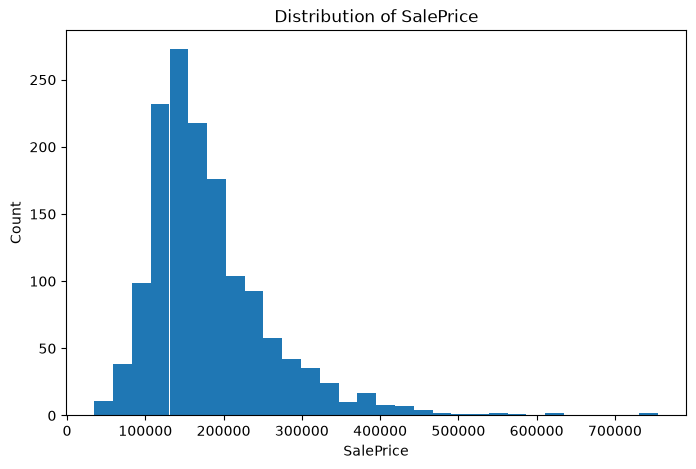

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_1['SalePrice'], bins=30)
plt.xlabel('SalePrice')
plt.ylabel('Count')
plt.title('Distribution of SalePrice')
plt.show()

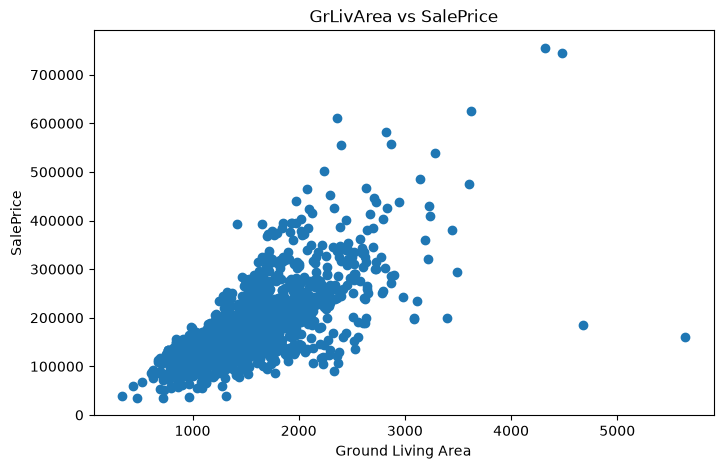

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(df_1['GrLivArea'], df_1['SalePrice'])
plt.xlabel('Ground Living Area')
plt.ylabel('SalePrice')
plt.title('GrLivArea vs SalePrice')
plt.show()

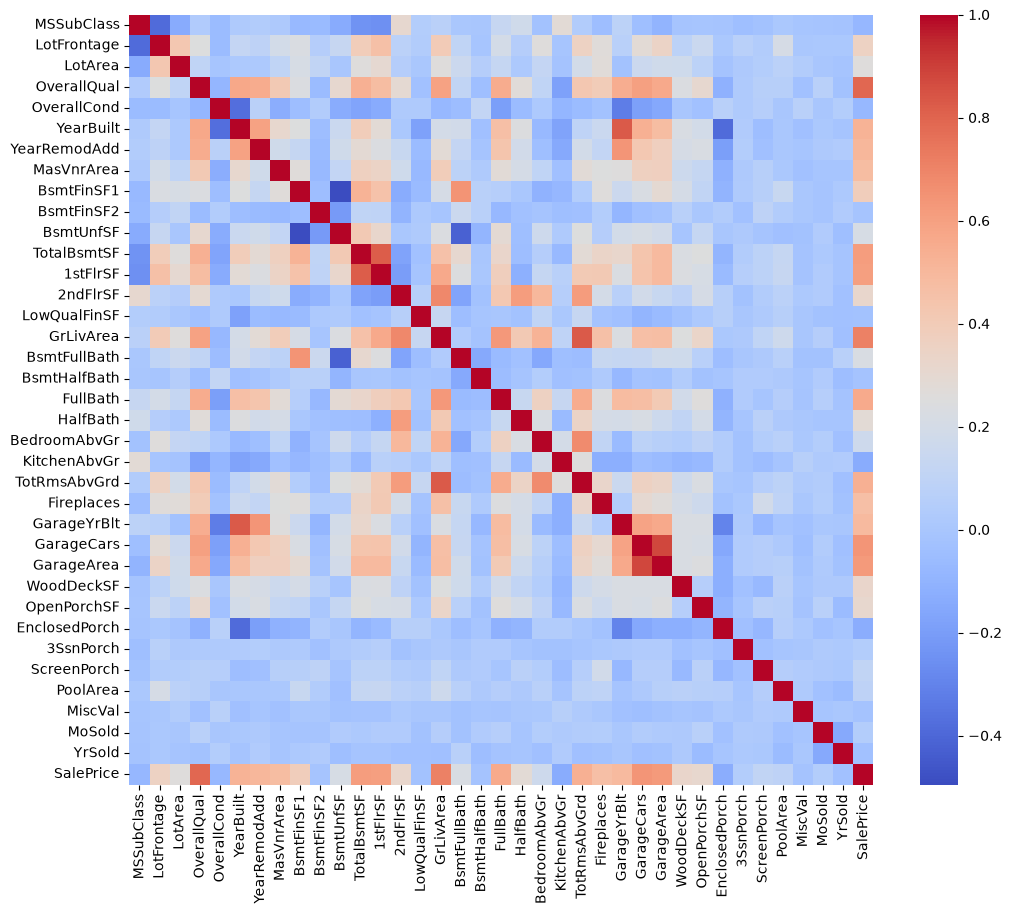

In [17]:
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(df_1.corr(numeric_only=True),
            cmap='coolwarm',
            annot=False)

plt.show()

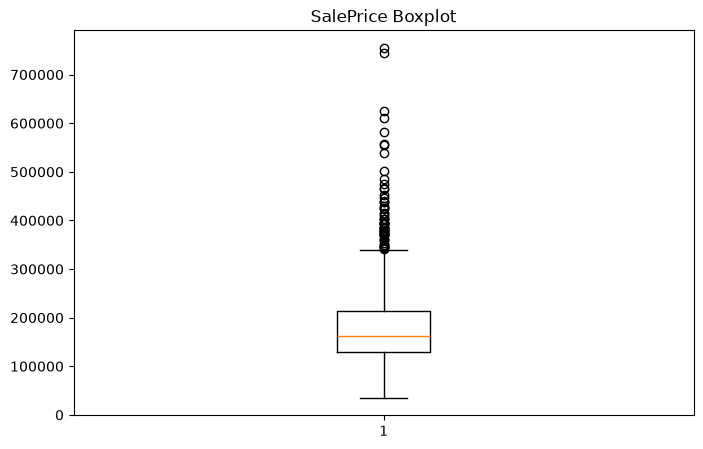

In [18]:
plt.figure(figsize=(8,5))
plt.boxplot(df_1['SalePrice'])
plt.title('SalePrice Boxplot')
plt.show()

In [19]:
target_coorelation = df_1.select_dtypes(include=[np.number]).corr()['SalePrice'].abs()

In [20]:
target_coorelation

MSSubClass       0.084284
LotFrontage      0.351799
LotArea          0.263843
OverallQual      0.790982
OverallCond      0.077856
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.477493
BsmtFinSF1       0.386420
BsmtFinSF2       0.011378
BsmtUnfSF        0.214479
TotalBsmtSF      0.613581
1stFlrSF         0.605852
2ndFlrSF         0.319334
LowQualFinSF     0.025606
GrLivArea        0.708624
BsmtFullBath     0.227122
BsmtHalfBath     0.016844
FullBath         0.560664
HalfBath         0.284108
BedroomAbvGr     0.168213
KitchenAbvGr     0.135907
TotRmsAbvGrd     0.533723
Fireplaces       0.466929
GarageYrBlt      0.486362
GarageCars       0.640409
GarageArea       0.623431
WoodDeckSF       0.324413
OpenPorchSF      0.315856
EnclosedPorch    0.128578
3SsnPorch        0.044584
ScreenPorch      0.111447
PoolArea         0.092404
MiscVal          0.021190
MoSold           0.046432
YrSold           0.028923
SalePrice        1.000000
Name: SalePrice, dtype: float64

In [21]:
low_imapct_threshold = 0.1



low_impact_cols = target_coorelation[target_coorelation<low_imapct_threshold].index.to_list()
low_impact_cols

['MSSubClass',
 'OverallCond',
 'BsmtFinSF2',
 'LowQualFinSF',
 'BsmtHalfBath',
 '3SsnPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

In [22]:
df_2 = df_1.drop(columns=low_impact_cols, errors='ignore')

In [23]:
df_2.shape

(1460, 66)

In [24]:
corr_matrix = df_2.select_dtypes(include=[np.number]).corr().abs()


In [25]:
np.triu(np.ones(corr_matrix.shape),k= 1)

array([[0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],


In [26]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))

upper

,LotFrontage,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SalePrice
LotFrontage,NaN,0.426095,0.251646,0.123349,0.088866,0.193458,0.233633,0.132644,0.392075,0.457181,...,0.352096,0.266639,0.070250,0.285691,0.344997,0.088521,0.151972,0.010700,0.041383,0.351799
LotArea,NaN,NaN,0.105806,0.014228,0.013788,0.104160,0.214103,0.002618,0.260833,0.299475,...,0.190015,0.271364,0.024947,0.154871,0.180403,0.171698,0.084774,0.018340,0.043160,0.263843
OverallQual,NaN,NaN,NaN,0.572323,0.550684,0.411876,0.239666,0.308159,0.537808,0.476224,...,0.427452,0.396765,0.547766,0.600671,0.562022,0.238923,0.308819,0.113937,0.064886,0.790982
YearBuilt,NaN,NaN,NaN,NaN,0.592855,0.315707,0.249503,0.149040,0.391452,0.281986,...,0.095589,0.147716,0.825667,0.537850,0.478954,0.224880,0.188686,0.387268,0.050364,0.522897
YearRemodAdd,NaN,NaN,NaN,NaN,NaN,0.179618,0.128451,0.181133,0.291066,0.240379,...,0.191740,0.112581,0.642277,0.420622,0.371600,0.205726,0.226298,0.193919,0.038740,0.507101
MasVnrArea,NaN,NaN,NaN,NaN,NaN,NaN,0.264736,0.114442,0.363936,0.344501,...,0.280682,0.249070,0.252691,0.364204,0.373066,0.159718,0.125703,0.110204,0.061466,0.477493
BsmtFinSF1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.495251,0.522396,0.445863,...,0.044316,0.260011,0.153484,0.224054,0.296970,0.204306,0.111761,0.102303,0.062021,0.386420
BsmtUnfSF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.415360,0.317987,...,0.250647,0.051575,0.190708,0.214175,0.183303,0.005316,0.129005,0.002538,0.012579,0.214479
TotalBsmtSF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.819530,...,0.285573,0.339519,0.322445,0.434585,0.486665,0.232019,0.247264,0.095478,0.084489,0.613581
1stFlrSF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.409516,0.410531,0.233449,0.439317,0.489782,0.235459,0.211671,0.065292,0.088758,0.605852


In [27]:
upper.columns

Index(['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd',
       'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
       '2ndFlrSF', 'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', 'ScreenPorch', 'SalePrice'],
      dtype='str')

In [28]:
redundant_cols = [ column for column in upper.columns if any(upper[column] > 0.8)]
redundant_cols


['1stFlrSF', 'TotRmsAbvGrd', 'GarageYrBlt', 'GarageArea']

In [29]:
df_3 = df_2.drop(columns= redundant_cols , errors = 'ignore')
df_3

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


In [30]:
df_3.info

<bound method DataFrame.info of      MSZoning  LotFrontage  LotArea Street LotShape LandContour Utilities  \
0          RL         65.0     8450   Pave      Reg         Lvl    AllPub   
1          RL         80.0     9600   Pave      Reg         Lvl    AllPub   
2          RL         68.0    11250   Pave      IR1         Lvl    AllPub   
3          RL         60.0     9550   Pave      IR1         Lvl    AllPub   
4          RL         84.0    14260   Pave      IR1         Lvl    AllPub   
...       ...          ...      ...    ...      ...         ...       ...   
1455       RL         62.0     7917   Pave      Reg         Lvl    AllPub   
1456       RL         85.0    13175   Pave      Reg         Lvl    AllPub   
1457       RL         66.0     9042   Pave      Reg         Lvl    AllPub   
1458       RL         68.0     9717   Pave      Reg         Lvl    AllPub   
1459       RL         75.0     9937   Pave      Reg         Lvl    AllPub   

     LotConfig LandSlope Neighborhood  ... 

In [31]:
df_3.head(7
          )

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
5,RL,85.0,14115,Pave,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,...,TA,TA,Y,40,30,0,0,WD,Normal,143000
6,RL,75.0,10084,Pave,Reg,Lvl,AllPub,Inside,Gtl,Somerst,...,TA,TA,Y,255,57,0,0,WD,Normal,307000


# Imputation with Missing Values

In [32]:
missing_values = df_3.isnull().sum()
missing_values = missing_values[missing_values>0].sort_values(ascending=False
                                                              )
missing_values

MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageType       81
GarageQual       81
GarageFinish     81
GarageCond       81
BsmtFinType2     38
BsmtExposure     38
BsmtQual         37
BsmtFinType1     37
BsmtCond         37
MasVnrArea        8
Electrical        1
dtype: int64

In [33]:
df_mean = df_3.copy()
df_mean.fillna({"LotFrontage": df_mean["LotFrontage"].mean()},inplace=True)



,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


In [34]:
df_median = df_3.copy()
df_median.fillna({"Lotfrontage": df_median["LotFrontage"].median()},inplace=True)

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


In [35]:
df_mode = df_3.copy()
df_mode['GarageType'].unique()

<StringArray>
['Attchd', 'Detchd', 'BuiltIn', 'CarPort', nan, 'Basment', '2Types']
Length: 7, dtype: str

In [36]:
df_mode['GarageType'].mode()[0]

# df_mode['GarageType'].value_counts()

'Attchd'

In [37]:
df_mode.fillna({"GarageType": df_mode["GarageType"].mode()},inplace=True)

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,...,TA,TA,Y,0,40,0,0,WD,Normal,175000
1456,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,...,TA,TA,Y,349,0,0,0,WD,Normal,210000
1457,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,...,TA,TA,Y,0,60,0,0,WD,Normal,266500
1458,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,TA,TA,Y,366,0,112,0,WD,Normal,142125


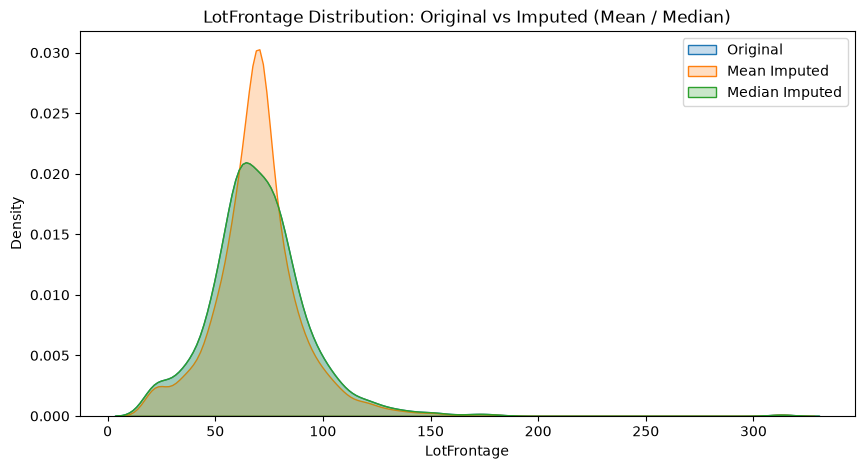

In [38]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df_3["LotFrontage"], label="Original", fill=True)
sns.kdeplot(df_mean["LotFrontage"], label="Mean Imputed", fill=True)
sns.kdeplot(df_median["LotFrontage"], label="Median Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Mean / Median)")
plt.show()

In [39]:
def compare_imputation(df_before, df_after, column_name):
    missing_indices = {column_name : df_before[df_before[column_name].isnull()].index.to_list() for column_name in df_before.columns if df_before[column_name].isnull().any()}

    if column_name not in missing_indices:
        print(f"No missing values were found in column '{column_name}'")
        return

    idx_list = missing_indices[column_name]

    comparison = pd.DataFrame({
        "Before" : df_before.loc[idx_list,column_name], 
        "After" : df_after.loc[idx_list,column_name], 
    })

    print(f"Changes in column : {column_name}")
    return comparison

compare_imputation(df_mean , df_mode , "LotFrontage" )

No missing values were found in column 'LotFrontage'


In [40]:
# !pip install scikit-learn

In [41]:
from sklearn.impute import KNNImputer

In [42]:
knn_imputer = KNNImputer(n_neighbors=5)

In [43]:
df_knn = df_3.copy()

In [44]:
numerical_cols = df_knn.select_dtypes(include=[np.number]).columns
numerical_cols

Index(['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd',
       'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '2ndFlrSF',
       'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'Fireplaces', 'GarageCars', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', 'ScreenPorch', 'SalePrice'],
      dtype='str')

In [45]:
df_knn[numerical_cols] = knn_imputer.fit_transform(df_knn[numerical_cols])

In [46]:
compare_imputation(df_3,df_knn,"LotFrontage").head(5)

Changes in column : LotFrontage


,Before,After
7,NaN,77.4
12,NaN,73.2
14,NaN,75.2
16,NaN,90.2
24,NaN,66.0


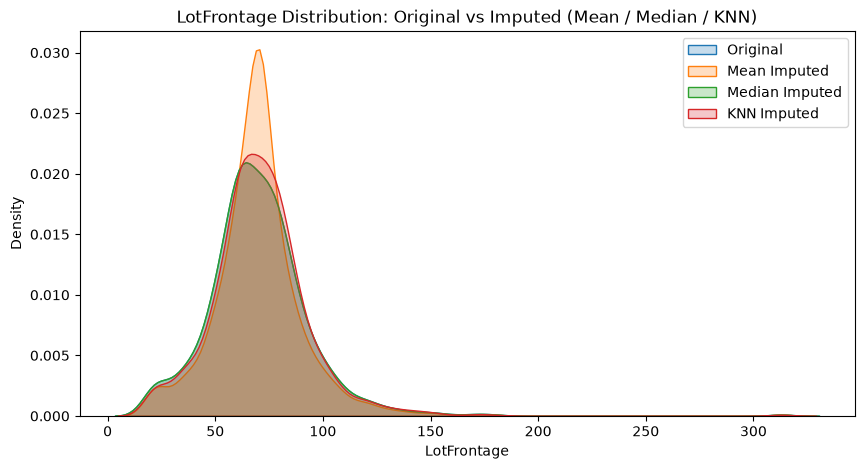

In [47]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df["LotFrontage"], label="Original", fill=True)
sns.kdeplot(df_mean["LotFrontage"], label="Mean Imputed", fill=True)
sns.kdeplot(df_median["LotFrontage"], label="Median Imputed", fill=True)
sns.kdeplot(df_knn["LotFrontage"], label="KNN Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Mean / Median / KNN)")
plt.show()

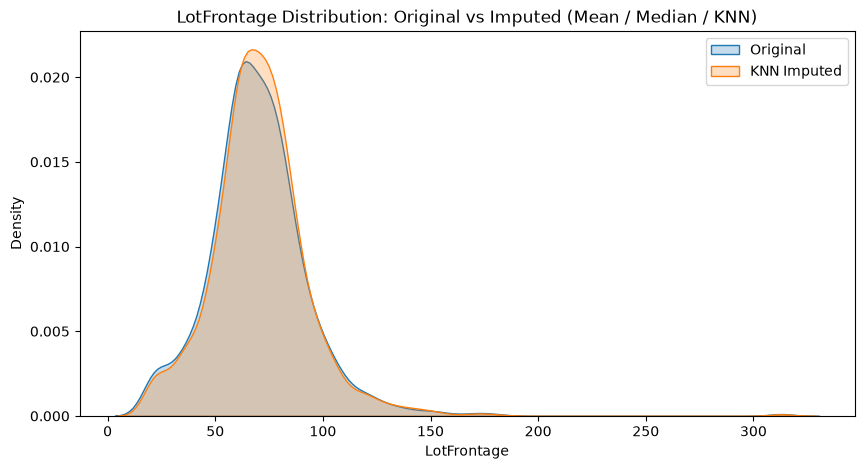

In [48]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df["LotFrontage"], label="Original", fill=True)
# sns.kdeplot(df_mean["LotFrontage"], label="Mean Imputed", fill=True)
# sns.kdeplot(df_median["LotFrontage"], label="Median Imputed", fill=True)
sns.kdeplot(df_knn["LotFrontage"], label="KNN Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Mean / Median / KNN)")
plt.show()

In [49]:
from sklearn.linear_model import LinearRegression

In [50]:
df_reg = df_3.copy()

In [51]:
train_data = df_reg.dropna(subset=['LotFrontage'])
test_data = df_reg[df_reg["LotFrontage"].isnull()]

In [52]:
test_data.info()

<class 'pandas.DataFrame'>
Index: 259 entries, 7 to 1446
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSZoning       259 non-null    str    
 1   LotFrontage    0 non-null      float64
 2   LotArea        259 non-null    int64  
 3   Street         259 non-null    str    
 4   LotShape       259 non-null    str    
 5   LandContour    259 non-null    str    
 6   Utilities      259 non-null    str    
 7   LotConfig      259 non-null    str    
 8   LandSlope      259 non-null    str    
 9   Neighborhood   259 non-null    str    
 10  Condition1     259 non-null    str    
 11  Condition2     259 non-null    str    
 12  BldgType       259 non-null    str    
 13  HouseStyle     259 non-null    str    
 14  OverallQual    259 non-null    int64  
 15  YearBuilt      259 non-null    int64  
 16  YearRemodAdd   259 non-null    int64  
 17  RoofStyle      259 non-null    str    
 18  RoofMatl       259 non-nu

In [53]:
target_coorelation_ml = train_data.select_dtypes(include=[np.number]).corr()['LotFrontage'].abs()
target_coorelation_ml

LotFrontage      1.000000
LotArea          0.426095
OverallQual      0.251646
YearBuilt        0.123349
YearRemodAdd     0.088866
MasVnrArea       0.193458
BsmtFinSF1       0.233633
BsmtUnfSF        0.132644
TotalBsmtSF      0.392075
2ndFlrSF         0.080177
GrLivArea        0.402797
BsmtFullBath     0.100949
FullBath         0.198769
HalfBath         0.053532
BedroomAbvGr     0.263170
KitchenAbvGr     0.006069
Fireplaces       0.266639
GarageCars       0.285691
WoodDeckSF       0.088521
OpenPorchSF      0.151972
EnclosedPorch    0.010700
ScreenPorch      0.041383
SalePrice        0.351799
Name: LotFrontage, dtype: float64

In [54]:
X_train = train_data[["LotArea", "OverallQual", "TotalBsmtSF", "GrLivArea"]]
y_train = train_data["LotFrontage"]

In [55]:
reg = LinearRegression(
    
)

In [56]:
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0. ,-1.5 , 0.01, 0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['LotArea','OverallQual','TotalBsmtSF','GrLivArea']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,39.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [57]:
reg.coef_

reg.intercept_ # without intercept the equations is incomplete

np.float64(39.49996798775228)

In [58]:
test_data.head()

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
7,RL,NaN,10382,Pave,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,...,TA,TA,Y,235,204,228,0,WD,Normal,200000
12,RL,NaN,12968,Pave,IR2,Lvl,AllPub,Inside,Gtl,Sawyer,...,TA,TA,Y,140,0,0,176,WD,Normal,144000
14,RL,NaN,10920,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,...,TA,TA,Y,0,213,176,0,WD,Normal,157000
16,RL,NaN,11241,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,NAmes,...,TA,TA,Y,0,0,0,0,WD,Normal,149000
24,RL,NaN,8246,Pave,IR1,Lvl,AllPub,Inside,Gtl,Sawyer,...,TA,TA,Y,406,90,0,0,WD,Normal,154000


In [59]:
df_reg["LotFrontage"].isnull().head(20)

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7      True
8     False
9     False
10    False
11    False
12     True
13    False
14     True
15    False
16     True
17    False
18    False
19    False
Name: LotFrontage, dtype: bool

In [60]:
train_data.head(20)

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,61,0,0,WD,Normal,208500
1,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,298,0,0,0,WD,Normal,181500
2,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,0,42,0,0,WD,Normal,223500
3,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,0,35,272,0,WD,Abnorml,140000
4,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,192,84,0,0,WD,Normal,250000
5,RL,85.0,14115,Pave,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,...,TA,TA,Y,40,30,0,0,WD,Normal,143000
6,RL,75.0,10084,Pave,Reg,Lvl,AllPub,Inside,Gtl,Somerst,...,TA,TA,Y,255,57,0,0,WD,Normal,307000
8,RM,51.0,6120,Pave,Reg,Lvl,AllPub,Inside,Gtl,OldTown,...,Fa,TA,Y,90,0,205,0,WD,Abnorml,129900
9,RL,50.0,7420,Pave,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,...,Gd,TA,Y,0,4,0,0,WD,Normal,118000
10,RL,70.0,11200,Pave,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,...,TA,TA,Y,0,0,0,0,WD,Normal,129500


In [61]:
df_reg.loc[df_reg["LotFrontage"].isnull() , "LotFrontage"] = reg.predict(test_data[["LotArea", "OverallQual", "TotalBsmtSF", "GrLivArea"]])

In [62]:
compare_imputation(df_3,df_reg,"LotFrontage")

Changes in column : LotFrontage


,Before,After
7,NaN,76.480215
12,NaN,65.575403
14,NaN,70.486403
16,NaN,64.762909
24,NaN,64.943935
...,...,...
1429,NaN,76.446718
1431,NaN,58.033347
1441,NaN,54.931820
1443,NaN,61.383217


In [63]:
df_reg.isnull().head(6)

,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,SaleType,SaleCondition,SalePrice
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


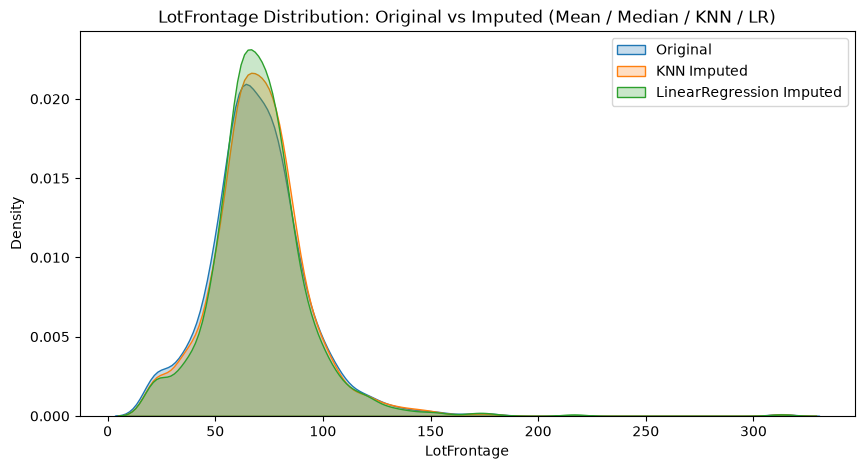

In [64]:
plt.figure(figsize=(10,5))
# kdeplot --> plot that shows pdf
sns.kdeplot(df_3["LotFrontage"], label="Original", fill=True)
sns.kdeplot(df_knn["LotFrontage"], label="KNN Imputed", fill=True)
sns.kdeplot(df_reg["LotFrontage"], label="LinearRegression Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution: Original vs Imputed (Mean / Median / KNN / LR)")
plt.show()


In [65]:
from scipy.stats import skew

In [66]:
data = [ 2 ,3 ,5 ,6 ,900]


In [67]:
print("Skewed Data" , skew(data))

Skewed Data 1.4999416130038297


### Filling missing values using Iterative Imputer (MICE)

In [68]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression

In [69]:
df = pd.read_csv("house-prices-advanced-regression-techniques/train.csv")

In [70]:
cols_to_use = ["LotFrontage", "LotArea", "OverallQual", "OverallCond", "1stFlrSF", "GrLivArea", "GarageYrBlt", "MasVnrArea"]

In [71]:
df[cols_to_use].info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LotFrontage  1201 non-null   float64
 1   LotArea      1460 non-null   int64  
 2   OverallQual  1460 non-null   int64  
 3   OverallCond  1460 non-null   int64  
 4   1stFlrSF     1460 non-null   int64  
 5   GrLivArea    1460 non-null   int64  
 6   GarageYrBlt  1379 non-null   float64
 7   MasVnrArea   1452 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 91.4 KB


In [72]:
df_subset = df[cols_to_use].copy()

In [73]:
df_subset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LotFrontage  1201 non-null   float64
 1   LotArea      1460 non-null   int64  
 2   OverallQual  1460 non-null   int64  
 3   OverallCond  1460 non-null   int64  
 4   1stFlrSF     1460 non-null   int64  
 5   GrLivArea    1460 non-null   int64  
 6   GarageYrBlt  1379 non-null   float64
 7   MasVnrArea   1452 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 91.4 KB


In [74]:
iter_imput = IterativeImputer(estimator=LinearRegression(), max_iter=10, random_state=10)


In [75]:
df_subset_imputed_values = iter_imput.fit_transform(df_subset)

In [76]:
df_subset[cols_to_use] = df_subset_imputed_values

In [77]:
df_subset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LotFrontage  1460 non-null   float64
 1   LotArea      1460 non-null   float64
 2   OverallQual  1460 non-null   float64
 3   OverallCond  1460 non-null   float64
 4   1stFlrSF     1460 non-null   float64
 5   GrLivArea    1460 non-null   float64
 6   GarageYrBlt  1460 non-null   float64
 7   MasVnrArea   1460 non-null   float64
dtypes: float64(8)
memory usage: 91.4 KB


In [78]:
df = df_3

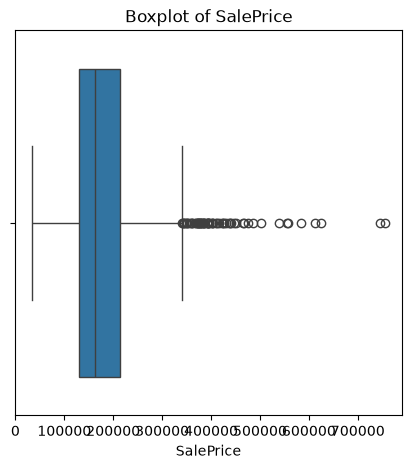

In [79]:
# Visualizing Outliers

plt.figure(figsize=(5,5))
sns.boxplot(x=df["SalePrice"])
plt.title("Boxplot of SalePrice")
plt.show()

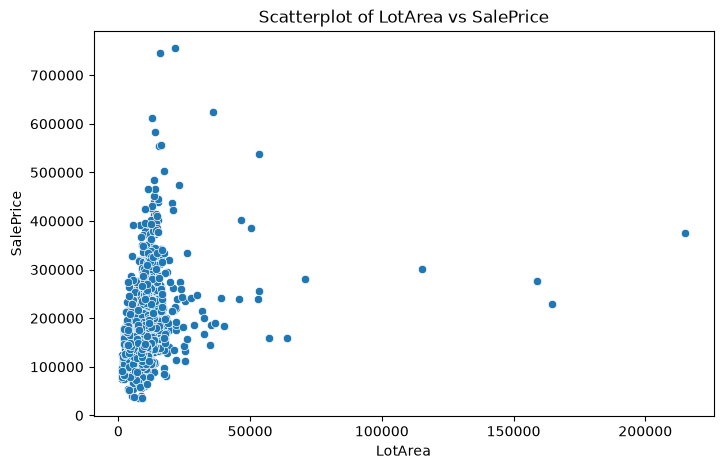

In [85]:
# Scatter plot LotArea vs SalePrice
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["LotArea"], y=df["SalePrice"])
plt.title("Scatterplot of LotArea vs SalePrice")
plt.show()

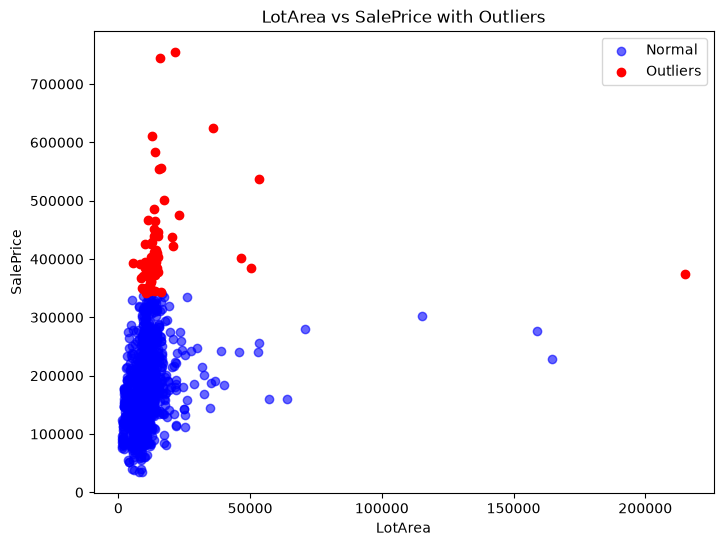

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate IQR for SalePrice
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Mark outliers
outliers = (df['SalePrice'] < lower) | (df['SalePrice'] > upper)

# Plot
plt.figure(figsize=(8,6))

# Normal points
plt.scatter(df.loc[~outliers, 'LotArea'],
            df.loc[~outliers, 'SalePrice'],
            color='blue', alpha=0.6, label='Normal')

# Outliers
plt.scatter(df.loc[outliers, 'LotArea'],
            df.loc[outliers, 'SalePrice'],
            color='red', label='Outliers')

plt.xlabel("LotArea")
plt.ylabel("SalePrice")
plt.title("LotArea vs SalePrice with Outliers")
plt.legend()
plt.show()





In [90]:
numeric_cols = df.select_dtypes(include='number').columns

outlier_rows = pd.Series(False, index=df.index)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_rows |= (df[col] < lower) | (df[col] > upper)

print("Total rows with at least one outlier:", outlier_rows.sum())

Total rows with at least one outlier: 678


In [92]:
outlier_data = df[outlier_rows]
print(outlier_data.index.tolist())

[3, 7, 8, 9, 11, 12, 14, 17, 21, 22, 25, 28, 29, 30, 36, 37, 39, 41, 46, 48, 53, 56, 58, 61, 63, 64, 66, 69, 70, 72, 74, 75, 78, 79, 80, 81, 82, 85, 86, 87, 88, 90, 92, 93, 98, 102, 104, 105, 108, 109, 112, 113, 115, 116, 118, 120, 121, 122, 126, 134, 137, 144, 145, 150, 151, 154, 155, 156, 159, 161, 164, 165, 166, 169, 171, 172, 173, 175, 176, 178, 179, 180, 181, 182, 183, 185, 188, 189, 193, 195, 196, 197, 198, 199, 202, 208, 210, 217, 218, 222, 224, 225, 227, 230, 231, 232, 235, 238, 242, 246, 249, 251, 259, 260, 271, 275, 276, 277, 278, 284, 286, 289, 290, 291, 292, 293, 297, 302, 304, 306, 309, 312, 313, 314, 316, 318, 320, 321, 324, 325, 328, 329, 330, 332, 335, 336, 339, 341, 342, 343, 349, 350, 351, 354, 357, 358, 359, 360, 362, 363, 364, 365, 366, 369, 371, 372, 375, 377, 378, 380, 383, 384, 385, 386, 389, 390, 391, 392, 400, 403, 407, 411, 412, 413, 414, 417, 419, 420, 422, 423, 425, 426, 429, 430, 432, 434, 437, 438, 440, 441, 446, 449, 451, 454, 456, 457, 459, 462, 466, 470

In [93]:
def detect_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3-Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_fence) | (data[col] > upper_fence)]
    return outliers[[col]]

In [97]:
outliers_saleprice = detect_outliers(df, "SalePrice")



In [98]:
print(f"No. of outliers in SalePrice : {len(outliers_saleprice)}")
display(outliers_saleprice.head())

No. of outliers in SalePrice : 61


,SalePrice
11,345000
53,385000
58,438780
112,383970
151,372402


In [99]:
import pandas as pd

# Function to detect outliers using IQR
def detect_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_fence) | (data[col] > upper_fence)]

    return outliers

# Get all numeric columns
numeric_cols = df.select_dtypes(include='number').columns

# Create an empty list to store results
results = []

# Loop through each numeric column
for col in numeric_cols:
    outliers = detect_outliers(df, col)
    count = len(outliers)

    print(f"{col}: {count} outliers")

    results.append({
        "Column": col,
        "Outlier Count": count
    })

# Convert results into a DataFrame
outlier_summary = pd.DataFrame(results)

print("\nSummary of Outliers:")
print(outlier_summary)

LotFrontage: 88 outliers
LotArea: 69 outliers
OverallQual: 2 outliers
YearBuilt: 7 outliers
YearRemodAdd: 0 outliers
MasVnrArea: 96 outliers
BsmtFinSF1: 7 outliers
BsmtUnfSF: 29 outliers
TotalBsmtSF: 61 outliers
2ndFlrSF: 2 outliers
GrLivArea: 31 outliers
BsmtFullBath: 1 outliers
FullBath: 0 outliers
HalfBath: 0 outliers
BedroomAbvGr: 35 outliers
KitchenAbvGr: 68 outliers
Fireplaces: 5 outliers
GarageCars: 5 outliers
WoodDeckSF: 32 outliers
OpenPorchSF: 77 outliers
EnclosedPorch: 208 outliers
ScreenPorch: 116 outliers
SalePrice: 61 outliers

Summary of Outliers:
           Column  Outlier Count
0     LotFrontage             88
1         LotArea             69
2     OverallQual              2
3       YearBuilt              7
4    YearRemodAdd              0
5      MasVnrArea             96
6      BsmtFinSF1              7
7       BsmtUnfSF             29
8     TotalBsmtSF             61
9        2ndFlrSF              2
10      GrLivArea             31
11   BsmtFullBath              1
12

In [100]:
import pandas as pd

# Function to detect outliers using IQR
def detect_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_fence) | (data[col] > upper_fence)]

    return outliers

# Select all numeric columns
numeric_cols = df.select_dtypes(include='number').columns

# Store results
results = []

for col in numeric_cols:
    outliers = detect_outliers(df, col)
    results.append({
        "Column": col,
        "Outlier Count": len(outliers)
    })

# Create DataFrame
outlier_summary = pd.DataFrame(results)

# Sort in descending order of outlier count
outlier_summary = outlier_summary.sort_values(
    by="Outlier Count",
    ascending=False
).reset_index(drop=True)

# Print the summary
print(outlier_summary)

           Column  Outlier Count
0   EnclosedPorch            208
1     ScreenPorch            116
2      MasVnrArea             96
3     LotFrontage             88
4     OpenPorchSF             77
5         LotArea             69
6    KitchenAbvGr             68
7     TotalBsmtSF             61
8       SalePrice             61
9    BedroomAbvGr             35
10     WoodDeckSF             32
11      GrLivArea             31
12      BsmtUnfSF             29
13      YearBuilt              7
14     BsmtFinSF1              7
15     GarageCars              5
16     Fireplaces              5
17       2ndFlrSF              2
18    OverallQual              2
19   BsmtFullBath              1
20   YearRemodAdd              0
21       HalfBath              0
22       FullBath              0
